# Анализ датасета flights (авиапассажиры 1949–1960)

## 1. Загружаем датасет flights

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# красивый стиль seaborn для всех графиков
sns.set_theme(style="whitegrid")

# загружаем встроенный датасет про авиапассажиров
flights = sns.load_dataset("flights")

# первые строки
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [ ]:
# типы данных по колонкам
flights.dtypes

## 2. Как росло число пассажиров со временем?

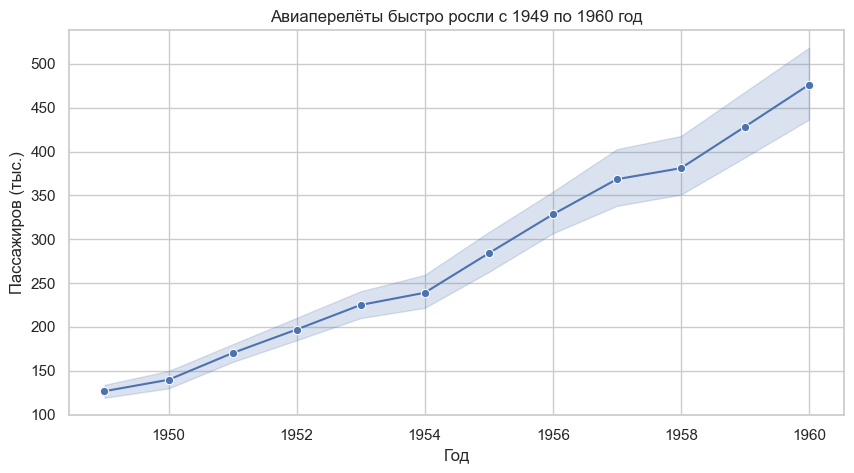

In [2]:
# линия: число пассажиров по месяцам за все годы
plt.figure(figsize=(10, 5))
sns.lineplot(data=flights, x="year", y="passengers", marker="o")
plt.title("Авиаперелёты быстро росли с 1949 по 1960 год")
plt.xlabel("Год")
plt.ylabel("Пассажиров (тыс.)")
plt.show()

## 3. Среднее число пассажиров по месяцам

/var/folders/66/3xy4pms51yv71qx6t0_h8ht00000gn/T/ipykernel_90725/1853067106.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flights, x="month", y="passengers", palette="viridis")


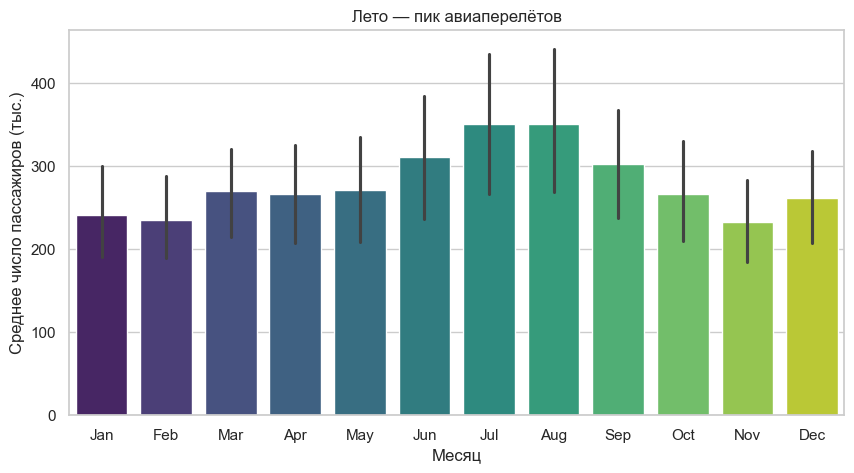

In [3]:
# среднее число пассажиров в каждом месяце
plt.figure(figsize=(10, 5))
sns.barplot(data=flights, x="month", y="passengers", palette="viridis")
plt.title("Лето — пик авиаперелётов")
plt.xlabel("Месяц")
plt.ylabel("Среднее число пассажиров (тыс.)")
plt.show()

## 4. Тепловая карта: год × месяц

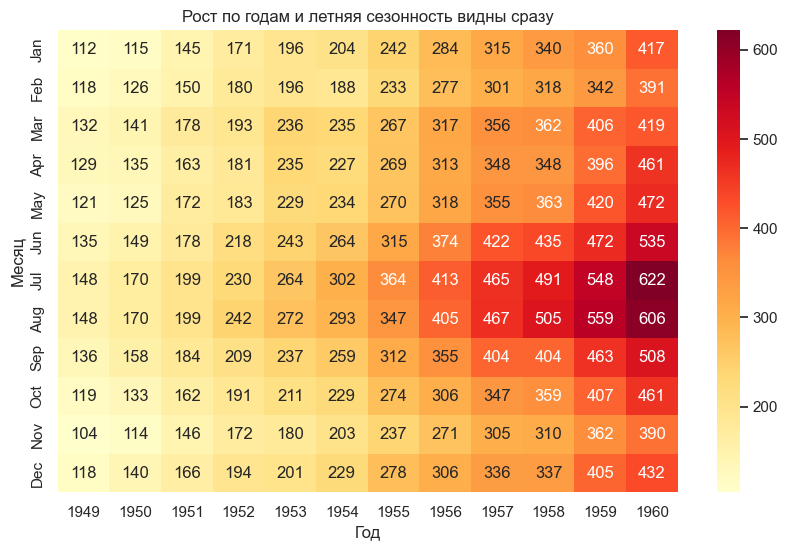

In [4]:
# превращаем таблицу в сетку: строки — месяцы, столбцы — годы
grid = flights.pivot(index="month", columns="year", values="passengers")

# тепловая карта: видно и рост по годам, и сезонность по месяцам
plt.figure(figsize=(10, 6))
sns.heatmap(grid, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Рост по годам и летняя сезонность видны сразу")
plt.xlabel("Год")
plt.ylabel("Месяц")
plt.show()

## 5. Распределение пассажиров — гистограмма

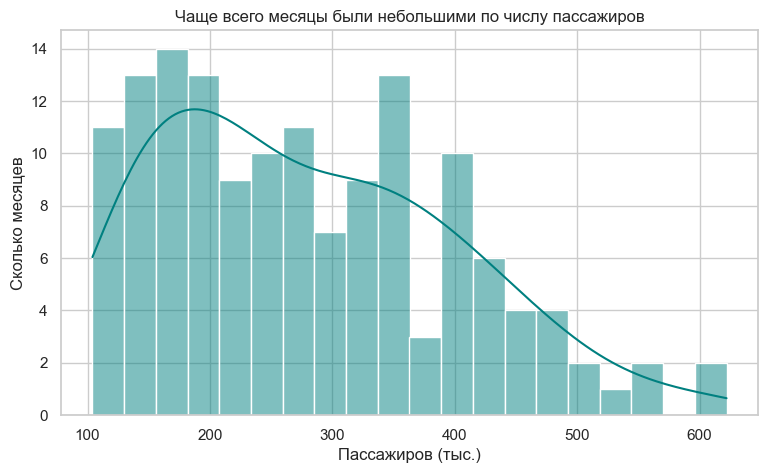

In [5]:
# распределение числа пассажиров по всем месяцам
plt.figure(figsize=(9, 5))
sns.histplot(data=flights, x="passengers", bins=20, kde=True, color="teal")
plt.title("Чаще всего месяцы были небольшими по числу пассажиров")
plt.xlabel("Пассажиров (тыс.)")
plt.ylabel("Сколько месяцев")
plt.show()

## 6. Разброс по месяцам — box plot

/var/folders/66/3xy4pms51yv71qx6t0_h8ht00000gn/T/ipykernel_90725/301509296.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flights, x="month", y="passengers", palette="coolwarm")


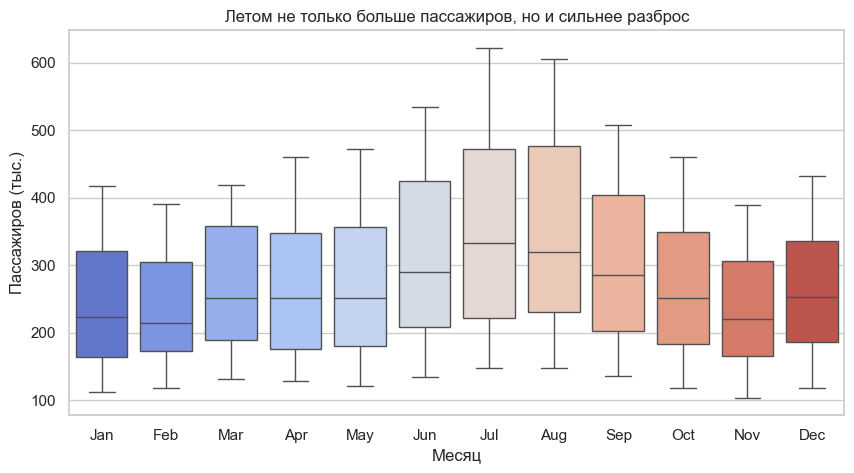

In [6]:
# box plot: разброс числа пассажиров внутри каждого месяца
plt.figure(figsize=(10, 5))
sns.boxplot(data=flights, x="month", y="passengers", palette="coolwarm")
plt.title("Летом не только больше пассажиров, но и сильнее разброс")
plt.xlabel("Месяц")
plt.ylabel("Пассажиров (тыс.)")
plt.show()

## 7. Каждый год — своя линия

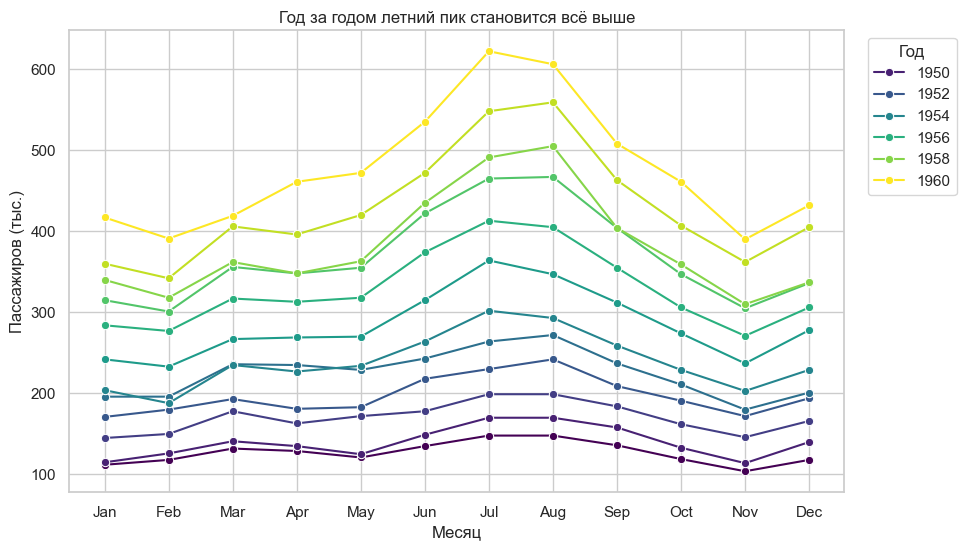

In [7]:
# линии по месяцам, каждый год своим цветом
plt.figure(figsize=(10, 6))
sns.lineplot(data=flights, x="month", y="passengers", hue="year", palette="viridis", marker="o")
plt.title("Год за годом летний пик становится всё выше")
plt.xlabel("Месяц")
plt.ylabel("Пассажиров (тыс.)")
plt.legend(title="Год", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 8. История из 3 графиков: что произошло с авиаперелётами?

/var/folders/66/3xy4pms51yv71qx6t0_h8ht00000gn/T/ipykernel_90725/3076975248.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly, x="year", y="passengers", palette="Blues")


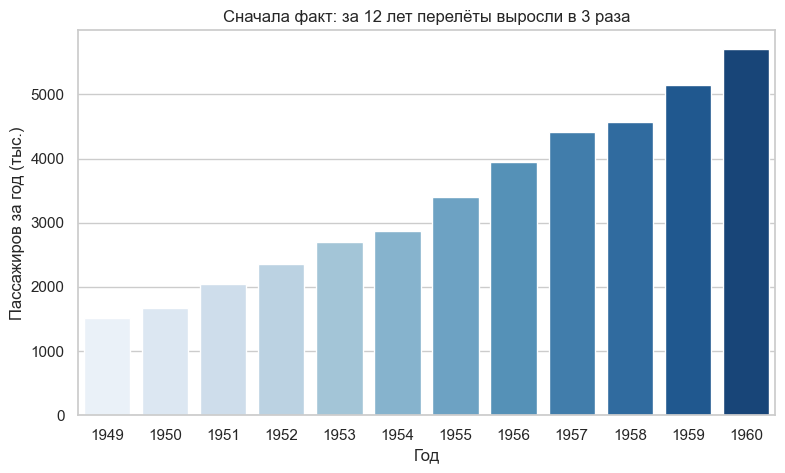

In [8]:
# график 1: общий рост по годам
yearly = flights.groupby("year")["passengers"].sum().reset_index()
plt.figure(figsize=(9, 5))
sns.barplot(data=yearly, x="year", y="passengers", palette="Blues")
plt.title("Сначала факт: за 12 лет перелёты выросли в 3 раза")
plt.xlabel("Год")
plt.ylabel("Пассажиров за год (тыс.)")
plt.show()

/var/folders/66/3xy4pms51yv71qx6t0_h8ht00000gn/T/ipykernel_90725/1072714797.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flights, x="month", y="passengers", palette="viridis")


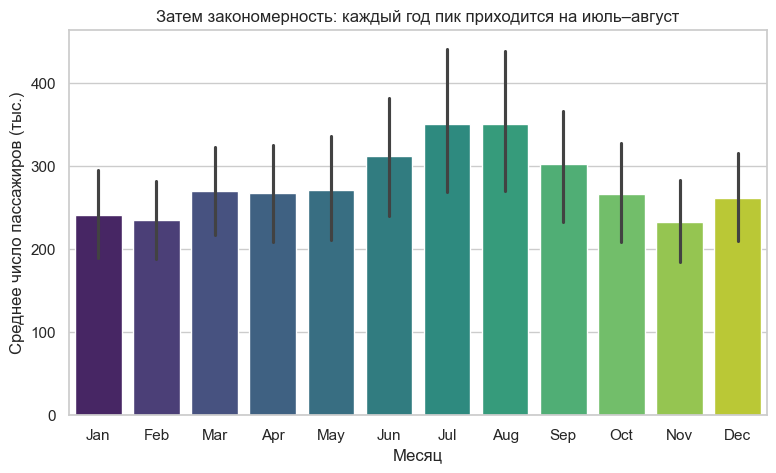

In [9]:
# график 2: внутри года есть устойчивая сезонность
plt.figure(figsize=(9, 5))
sns.barplot(data=flights, x="month", y="passengers", palette="viridis")
plt.title("Затем закономерность: каждый год пик приходится на июль–август")
plt.xlabel("Месяц")
plt.ylabel("Среднее число пассажиров (тыс.)")
plt.show()

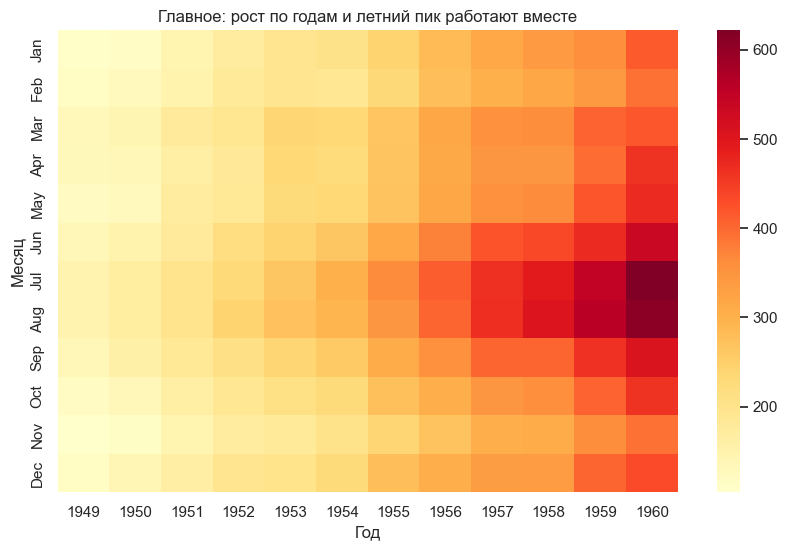

In [10]:
# график 3 (главный вывод): тепловая карта показывает оба эффекта сразу
plt.figure(figsize=(10, 6))
sns.heatmap(grid, cmap="YlOrRd")
plt.title("Главное: рост по годам и летний пик работают вместе")
plt.xlabel("Год")
plt.ylabel("Месяц")
plt.show()